# Step 3.1

Compute the R-hat convergence metric for MCMC chains

Requires two esperiments (two chains for each species)


In [1]:
import random
import os
import pandas
import datetime

from useful import rexp, format_timedelta, logit, logistic, rnorm
from numpy import array, log, exp, mean, std, linspace
from scipy import stats

import new_artist as artist

import data_pers
import plots

from load_data import *
import model

from scipy import stats

/home/shubin/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shubin/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
SL = DictOfUsedFish()

In [3]:
from numpy import ndarray


MEANS = {}
VARS = {}

NUM1 = '5_rep1'
NUM2 = '5'


def iterate_columns(H):
    for c in H.columns:
        if c in ['Prior', 'Likelihood', 'Posterior']: continue
        try:
            l = len(H[c][0])
            for i in range(l):
                yield (c, i), H[c].str[i]

        except:
            yield c, H[c]


print('today is', datetime.date.today().strftime('%d-%m-%Y'))
for i, s in enumerate(SL):
    print(i, s)
    
    try:
        TRIAL_N = f'samples/{NUM1}_{s.name}'
        H = data_pers.Load(TRIAL_N, files=[1])
        print(len(H), NUM1)        
        MEANS[s, 1] = {n: c.mean() for n, c in iterate_columns(H)}
        VARS[s, 1] = {n: c.var() for n, c in iterate_columns(H)}

        TRIAL_N = f'samples/{NUM2}_{s.name}'
        H = data_pers.Load(TRIAL_N, files=[1])   
        print(len(H), NUM2)        
        MEANS[s, 2] = {n: c.mean() for n, c in iterate_columns(H)}
        VARS[s, 2] = {n: c.var() for n, c in iterate_columns(H)}
    except:
        print('MISSING!')
    print()
    


today is 13-04-2026
0 her	126417	Atlantic herring
12114 5_rep1
30000 5

1 spr	126425	European sprat
30000 5_rep1
30000 5

2 stb	126505	Threespine stickleback
30000 5_rep1
30000 5

3 cod	126436	Atlantic cod
30000 5_rep1
30000 5

4 stb9	126507	Ninespine Stickleback
30000 5_rep1
30000 5

5 lumpf	127214	Lumpfish
30000 5_rep1
30000 5

6 whit	126438	Whiting
30000 5_rep1
30000 5

7 ach	126426	European anchovy
30000 5_rep1
30000 5

8 pom	125999	Goby
30000 5_rep1
30000 5

9 makr	126822	Atlantic horse mackerel
30000 5_rep1
30000 5

10 flo	127141	European flounder
30000 5_rep1
30000 5

11 smelt	126736	European smelt
30000 5_rep1
30000 5

12 dab	127139	Common dab
30000 5_rep1
30000 5

13 tgoby	126868	Transparent goby
30000 5_rep1
30000 5

14 pip	127385	Straightnose pipefish
30000 5_rep1
30000 5

15 wee	127082	Greater weever
30000 5_rep1
30000 5

16 snail	127219	Sea snail
30000 5_rep1
30000 5

17 amakr	127023	Atlantic mackerel
30000 5_rep1
30000 5

18 eel	126756	Great sand eel
30000 5_rep1
30000 5


In [4]:
SPECIES = [s for s in SL if (s, 1) in MEANS]
len(SPECIES)

45

In [5]:
def all_r_hat(s):
    out = []
    for k in MEANS[s, 1].keys():
        W = array([VARS[s, i][k]  for i in (1, 2)]).mean()
        B = array([MEANS[s, i][k] for i in (1, 2)]).var()
        out.append(((W+B)/W)**0.5)
    return out
    
all_r_hat(SL['spr'])[:10]

[1.0000849448737104,
 1.0000811355907835,
 1.0000369986832929,
 1.0000026060202598,
 1.000017288860165,
 1.0000917844329877,
 1.0000008624546202,
 1.0000460340306125,
 1.000004122294271,
 1.0000773808640233]

In [6]:
RHAT = {}

for i, s in enumerate(SPECIES):
    print(i, s.name)
    RHAT[s] = all_r_hat(s)
    

0 Atlantic herring
1 European sprat
2 Threespine stickleback
3 Atlantic cod
4 Ninespine Stickleback
5 Lumpfish
6 Whiting
7 European anchovy
8 Goby
9 Atlantic horse mackerel
10 European flounder
11 European smelt
12 Common dab
13 Transparent goby
14 Straightnose pipefish
15 Greater weever
16 Sea snail
17 Atlantic mackerel
18 Great sand eel
19 European plaice
20 Salmon
21 European eelpout
22 Grey gurnard
23 Shorthorn sculpin
24 Garfish
25 European river lamprey
26 Goldsinny wrasse
27 European sardine
28 Black goby
29 Common fangtooth
30 Lesser sand eel 
31 European hake
32 Turbot
33 Fourbeard rockling
34 Striped red mullet
35 Fourhorn sculpin
36 Snakeblenny
37 Hooknose
38 Brown trout
39 Mud shark
40 American plaice
41 European eel
42 Round goby 
43 Haddock
44 Zander


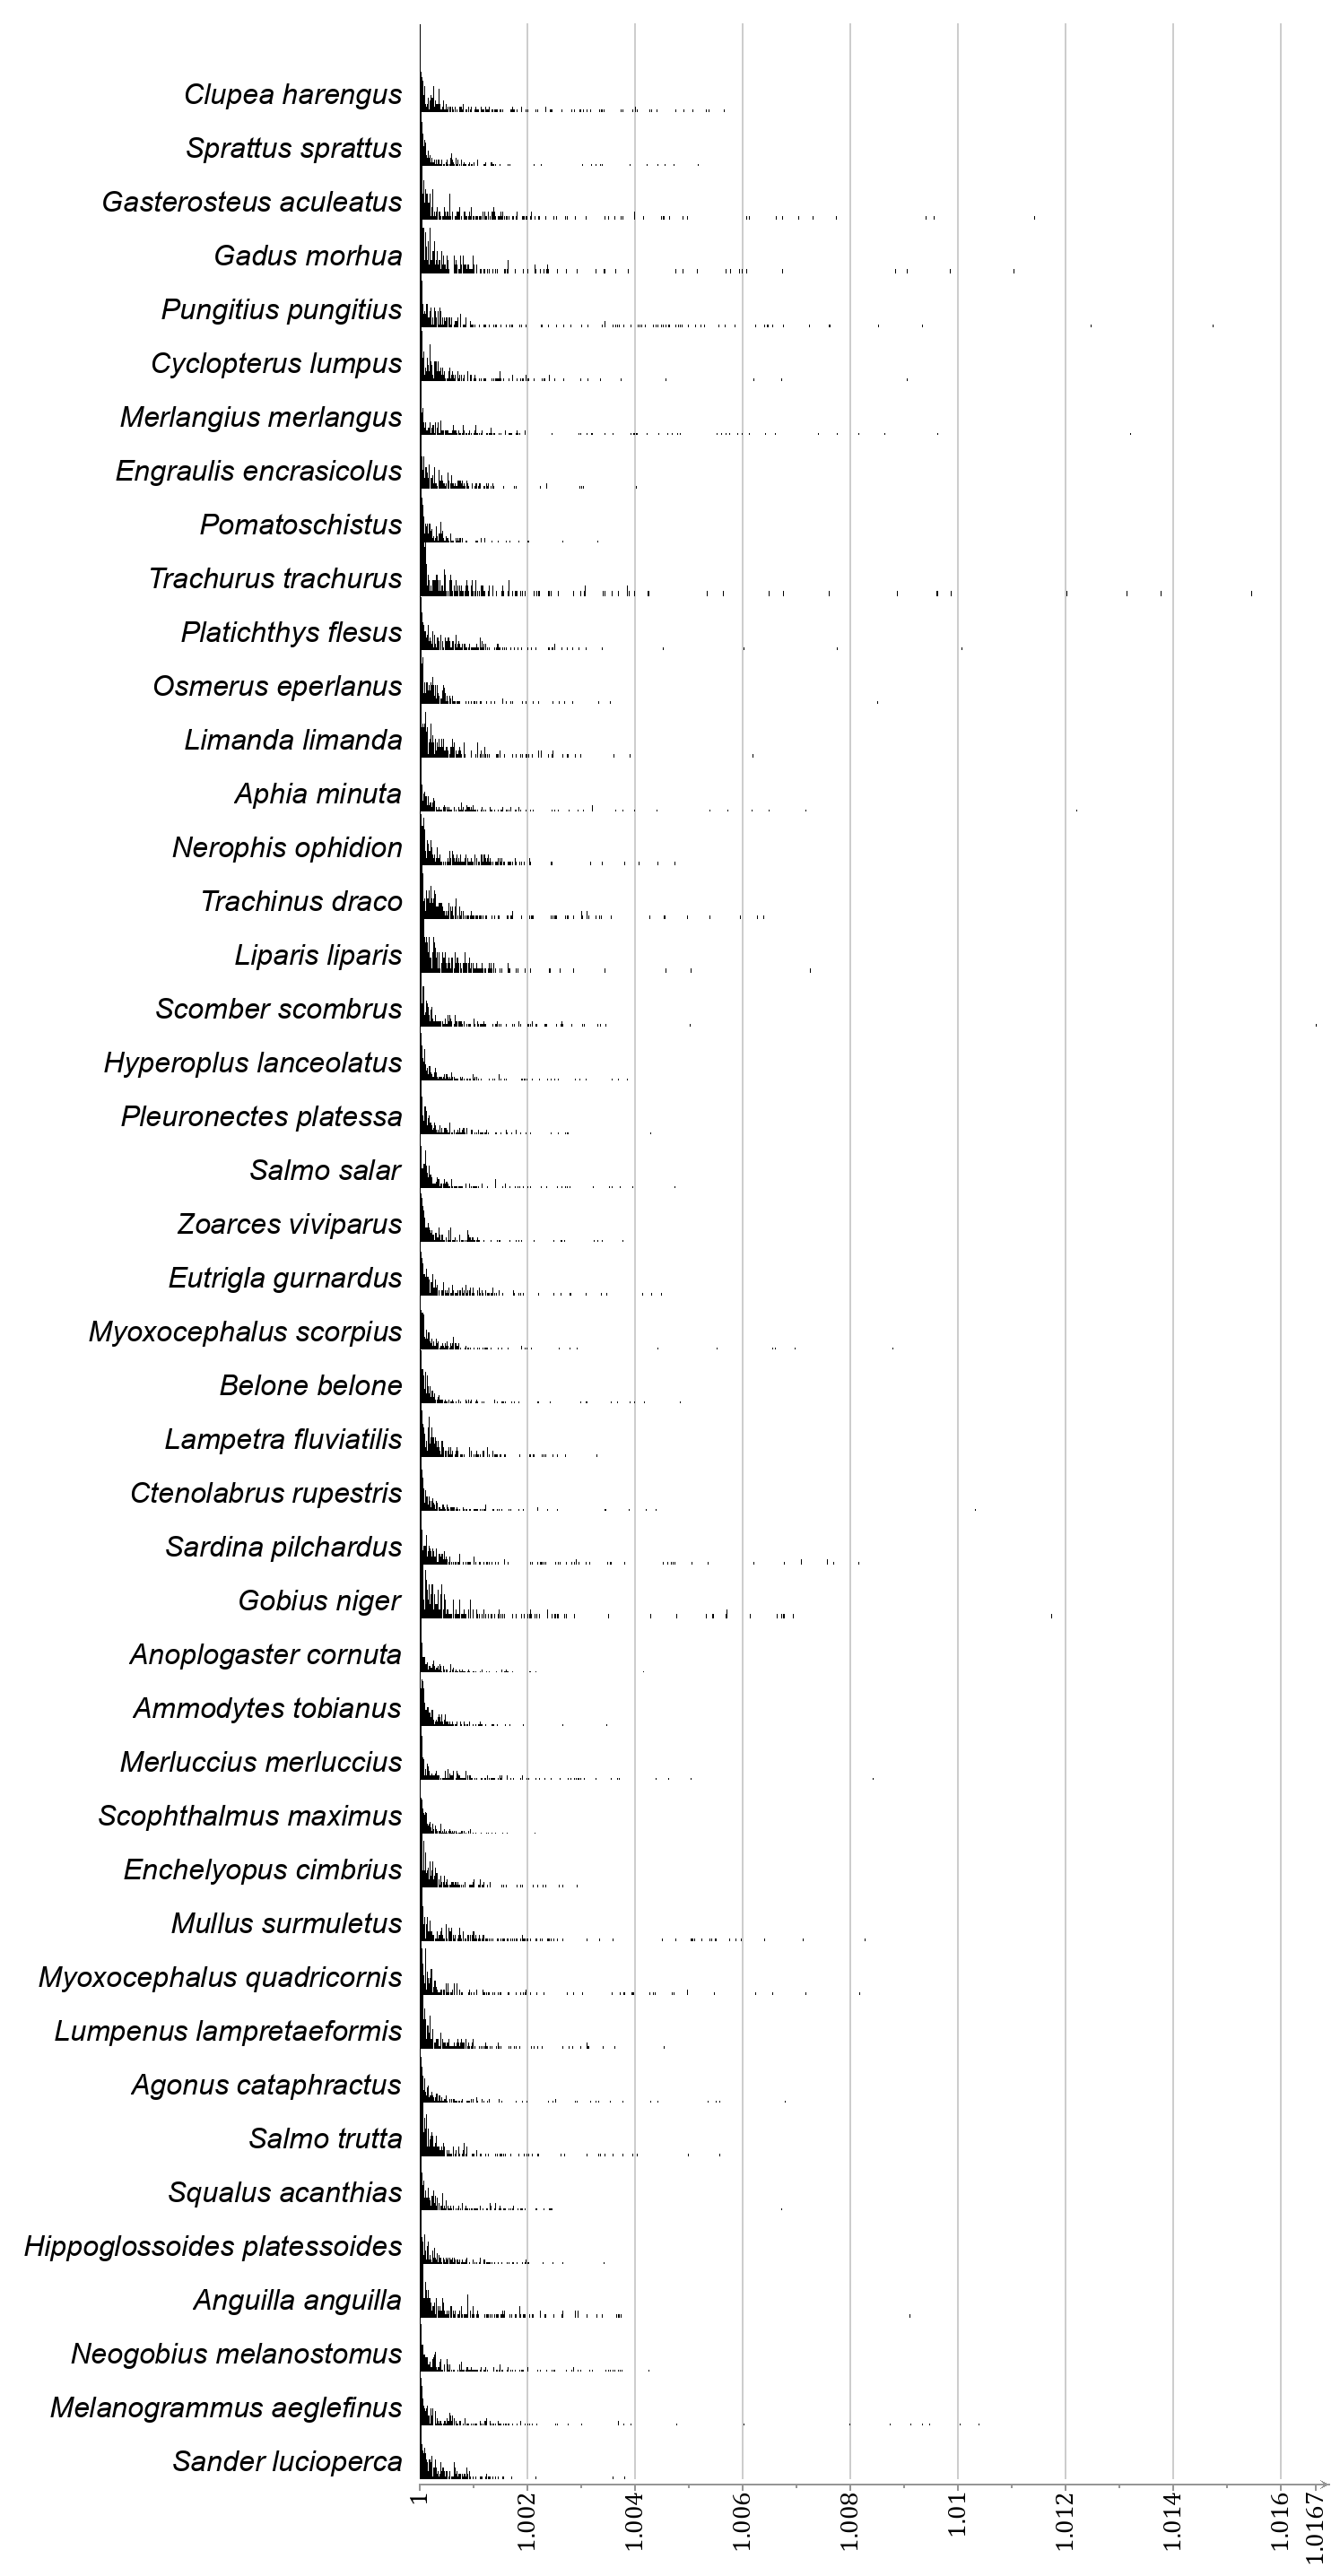

In [7]:
P = artist.Panel(1000, None, 'vv')

for i, s in enumerate(SPECIES):
    P.text(1, 0, SL[s].latin, pos='<^', font = (32, 'ariali.ttf')).move(-20, -i*60)
    P.hist(RHAT[SL[s]], height=98).move(0, -i*60)

P.grid('v', z=-1)
P.show()

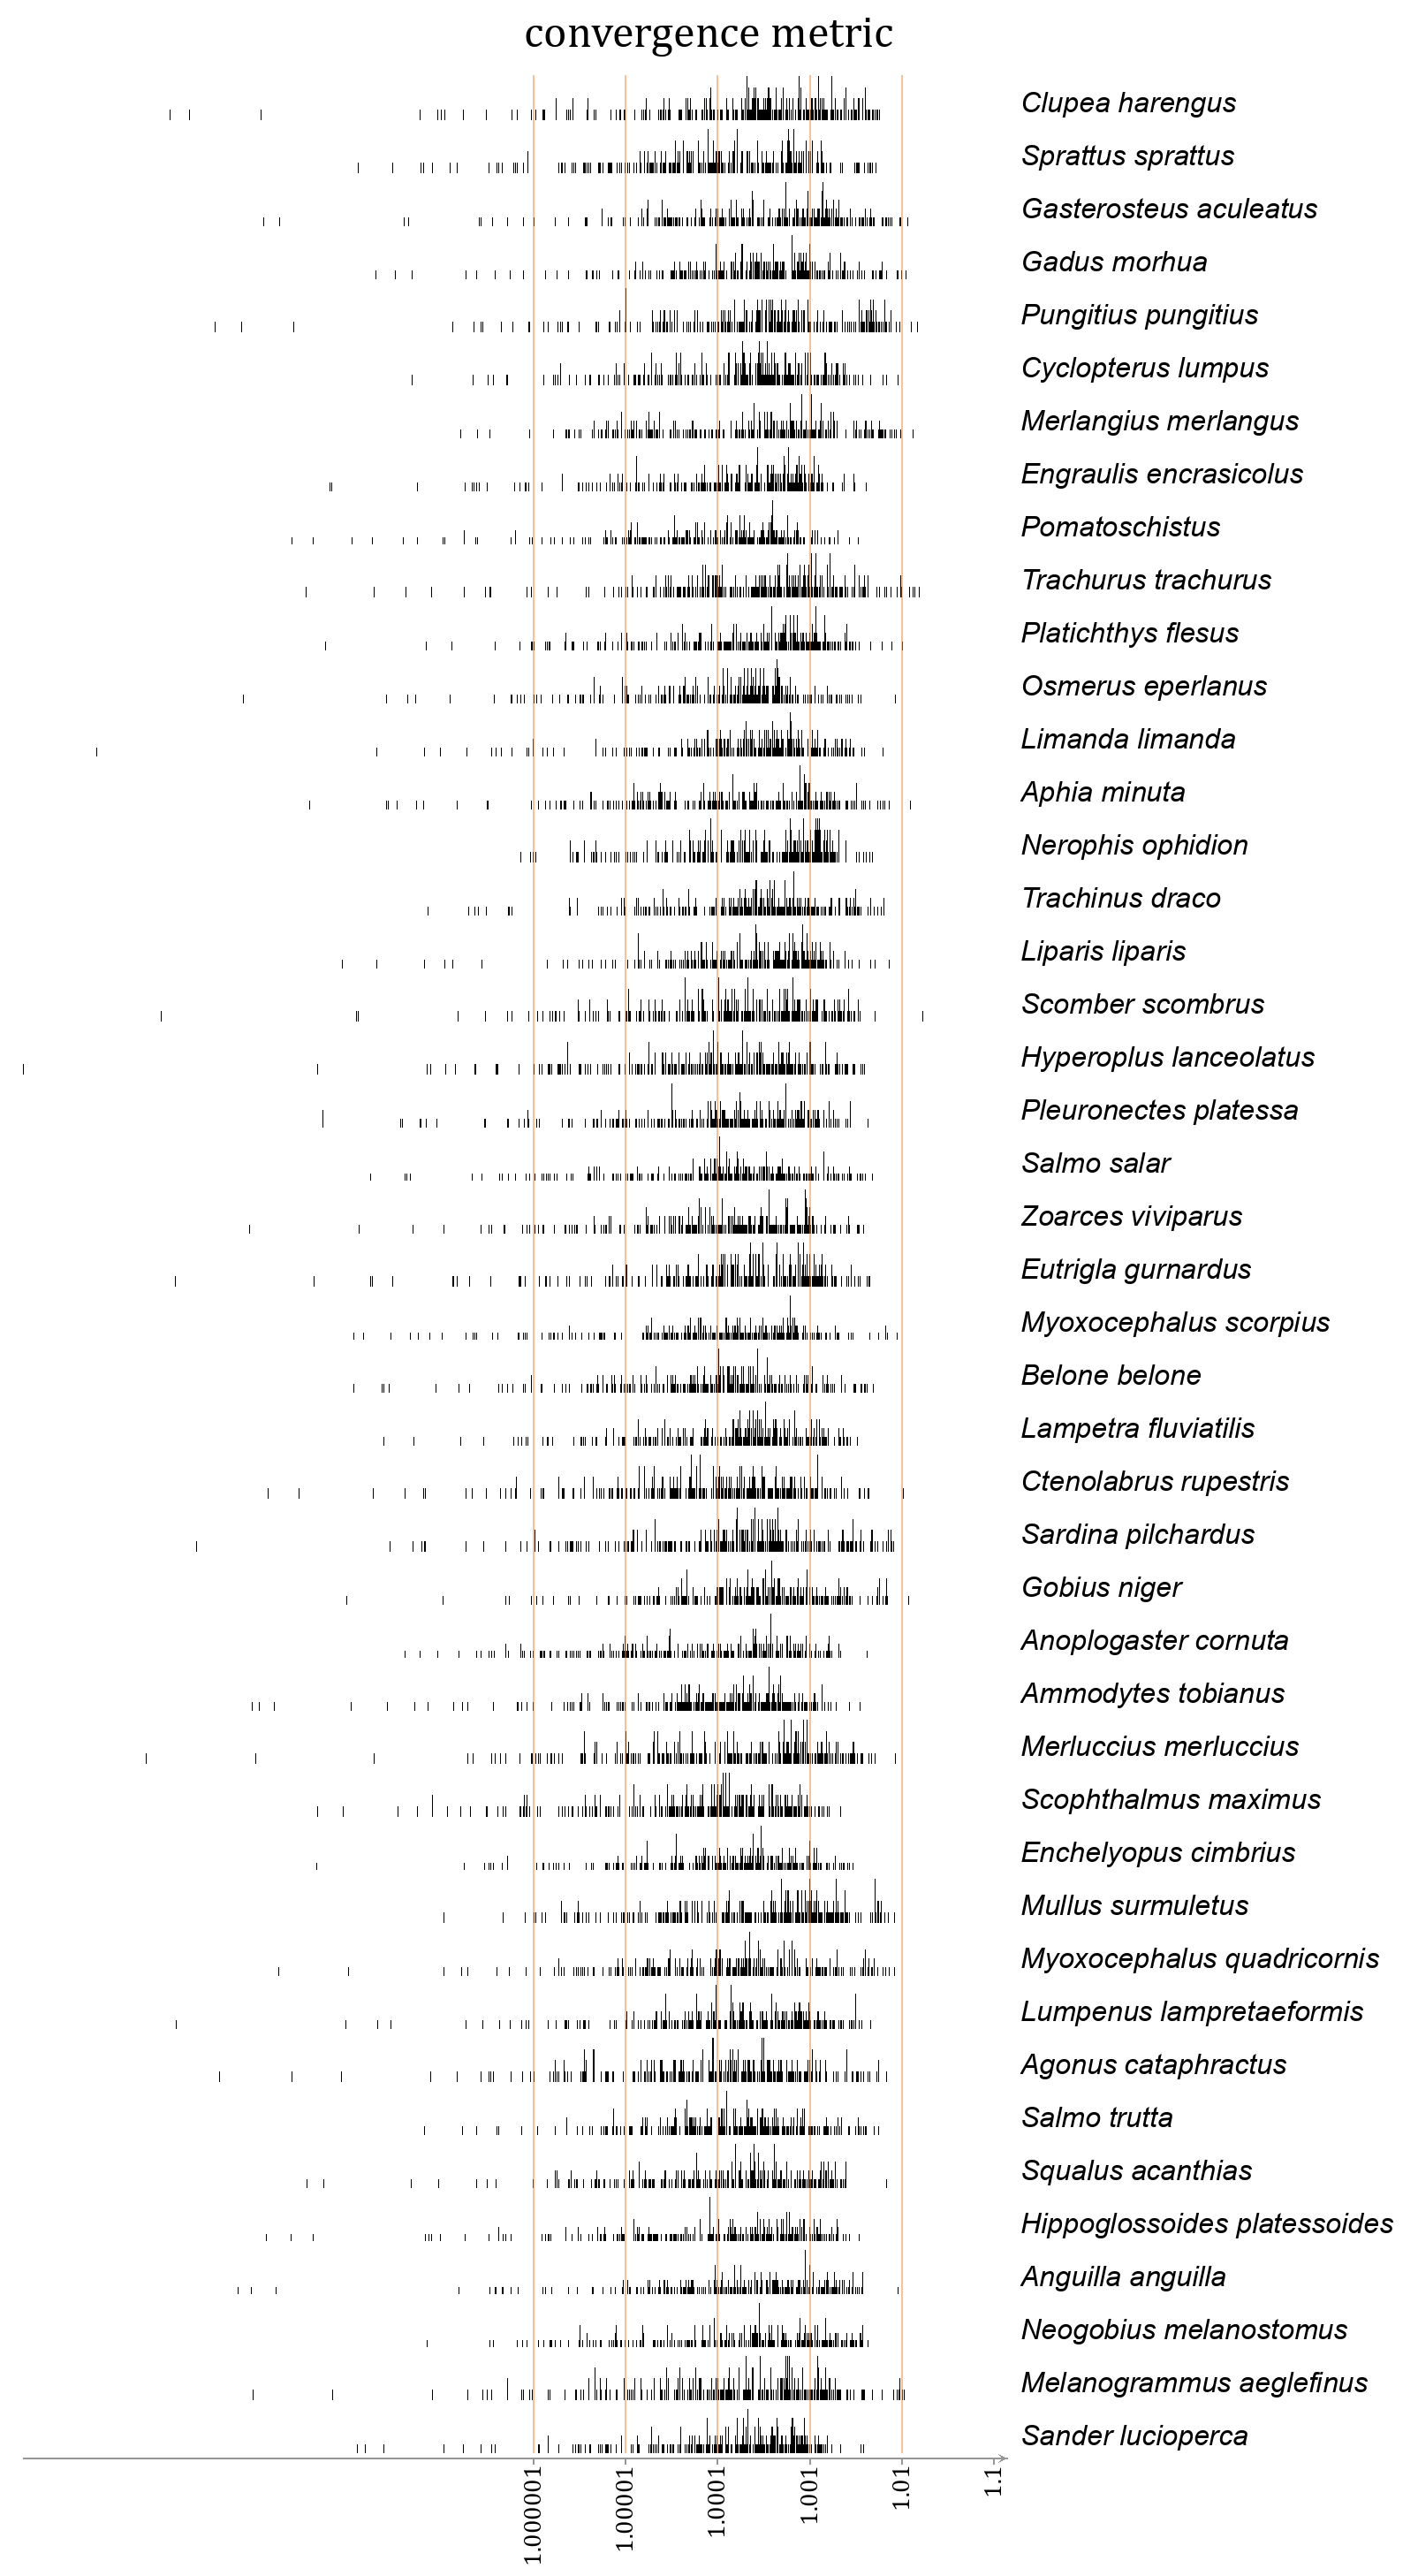

In [25]:
P = artist.Panel(('log', 1100), None, 'vv')

for i, s in enumerate(SPECIES):
    P.text(0.1, 0, SL[s].latin, pos='>^', font = (32, 'ariali.ttf')).move(30, -i*60)
    P.hist(array(RHAT[s])-1, height=50).move(0, -i*60)

P.bottom = {float(y)-1:str(y) for y in (1.000001, 1.00001, 1.0001, 1.001, 1.01, 1.1)}
P.grid('v', col='__o')
P.title = 'convergence metric'
P.title.font = 50
P.save(f'results_appendix/converence.png')

P.show()

In [9]:
# Zoom a single some species

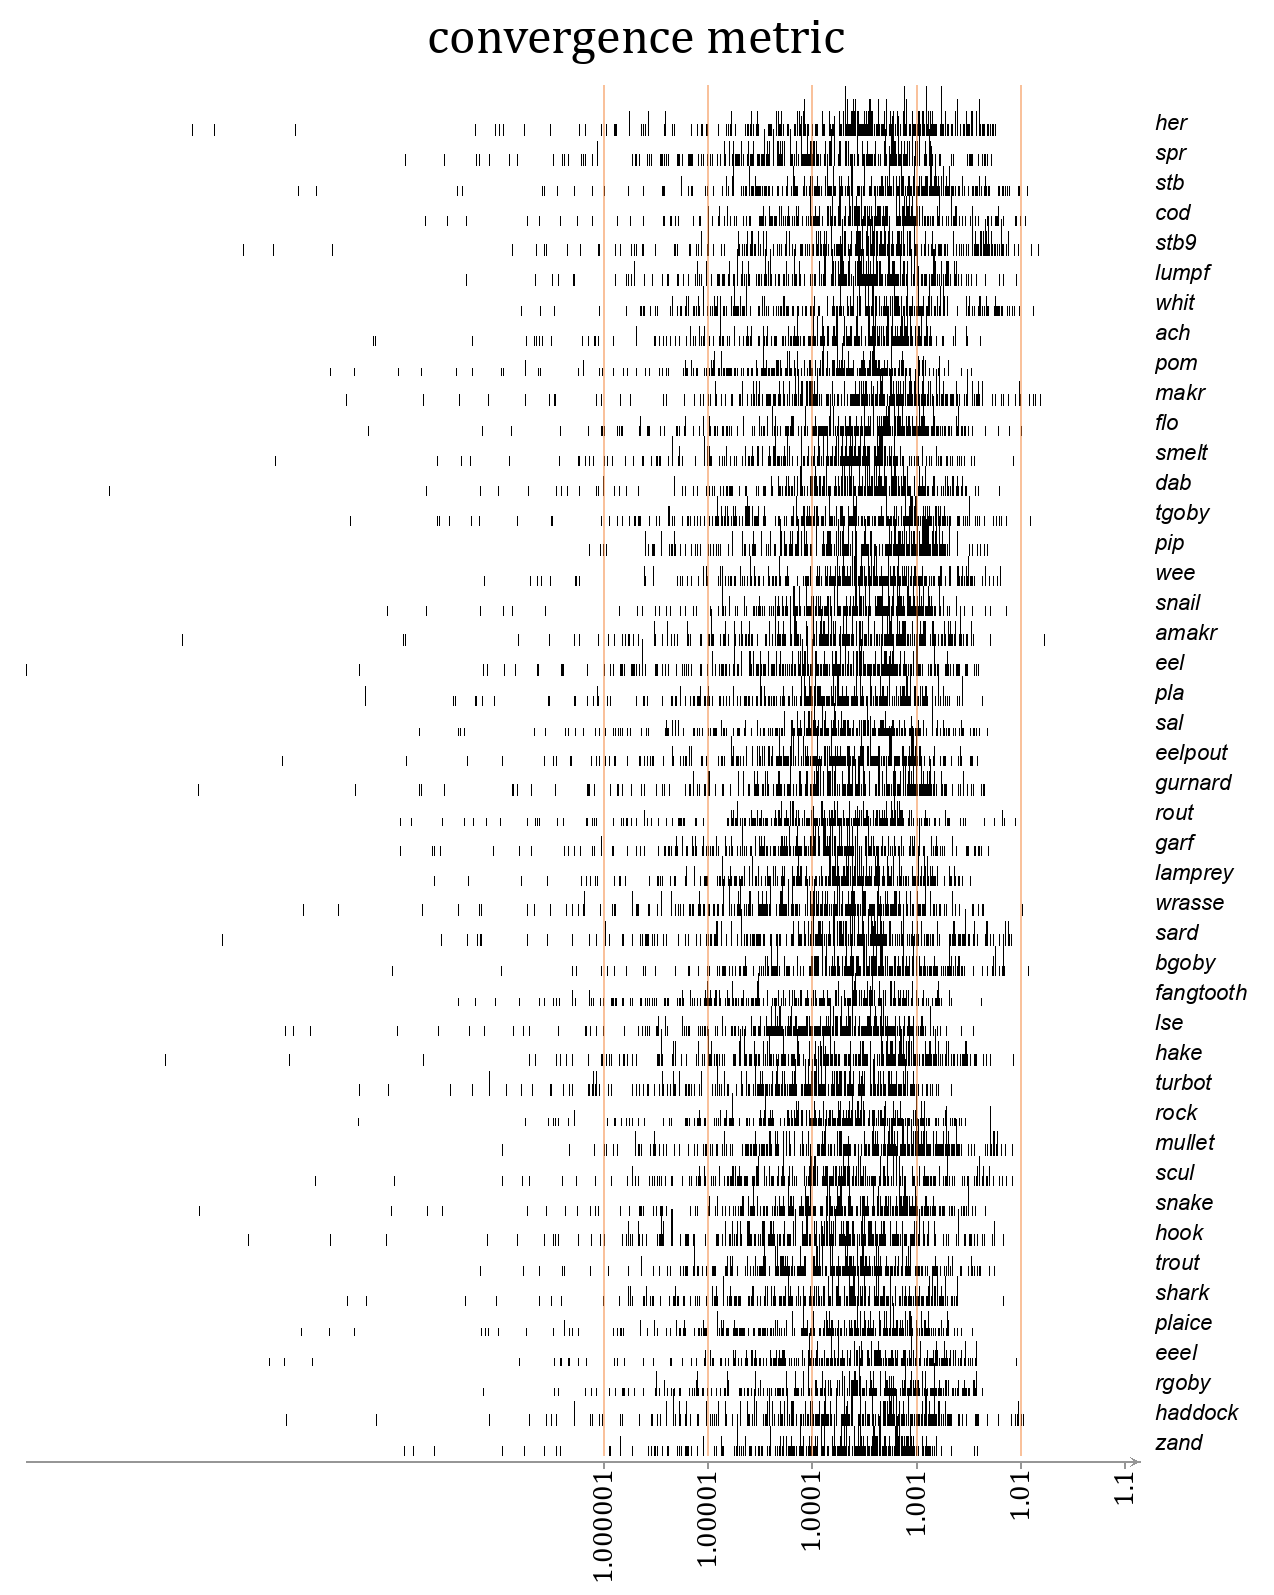

In [10]:
P = artist.Panel(('log', 1100), None, 'vv')

for i, s in enumerate(SPECIES):
    P.text(0.1, 0, SL[s].short, pos='>^', font = (22, 'ariali.ttf')).move(30, -i*30)
    P.hist(array(RHAT[s])-1, height=50).move(0, -i*30)

P.bottom = {float(y)-1:str(y) for y in (1.000001, 1.00001, 1.0001, 1.001, 1.01, 1.1)}
P.grid('v', col='__o')
P.title = 'convergence metric'
P.title.font = 50

P.show()

In [11]:
s = SL['flo']
s

flo	127141	European flounder

In [12]:

TRIAL_N = f'samples/{NUM1}_{s.name}'
H1 = data_pers.Load(TRIAL_N, files=[1])

TRIAL_N = f'samples/{NUM2}_{s.name}'
H2 = data_pers.Load(TRIAL_N, files=[1])   


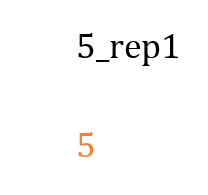

In [13]:
L = artist.Panel(100, 100)
L.text(0, 9, NUM1, col='k')
L.text(0, 0, NUM2, col='o')
L.show()


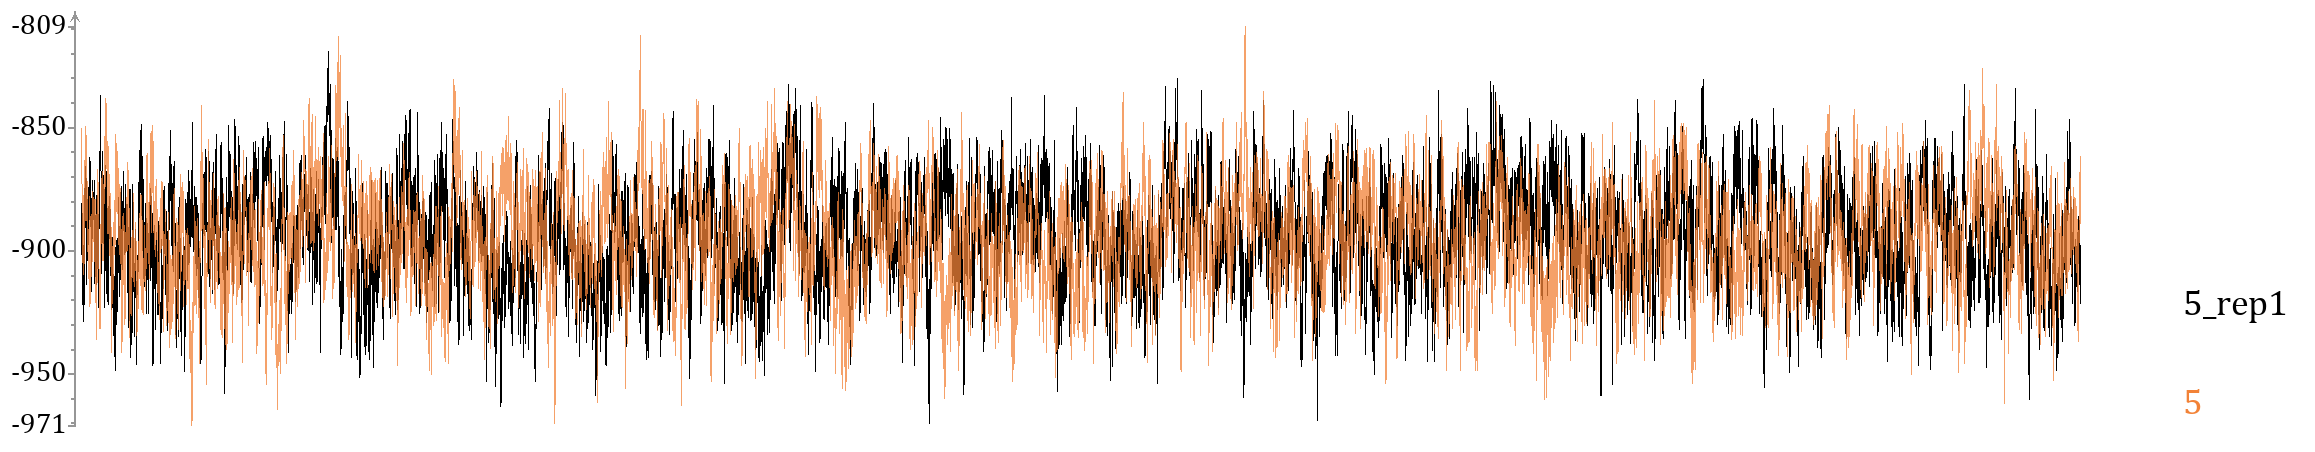

In [14]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.Posterior, p=1)
P.lines(H2.Posterior, col='_o', p=1)
(P+L).show()


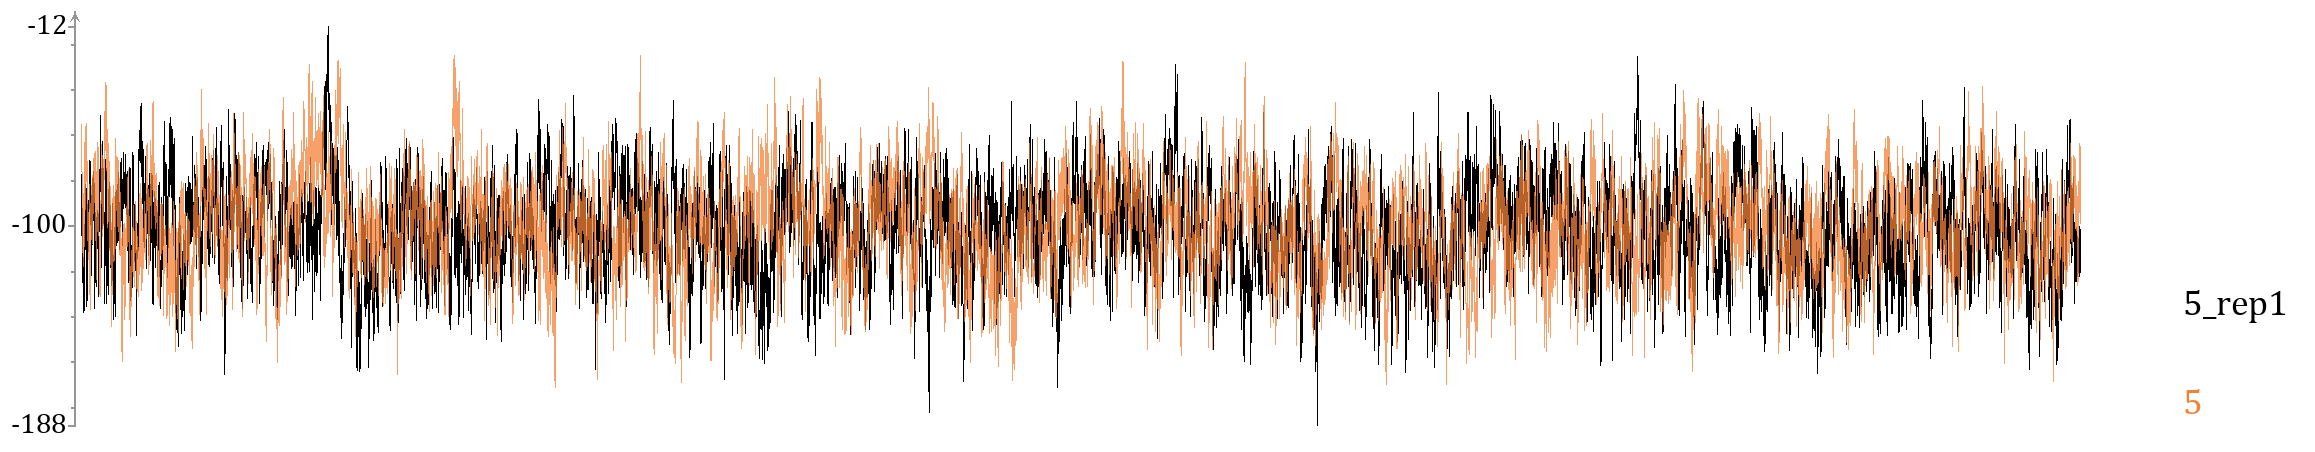

In [15]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.Prior, p=1)
P.lines(H2.Prior, col='_o', p=1)
(P+L).show()


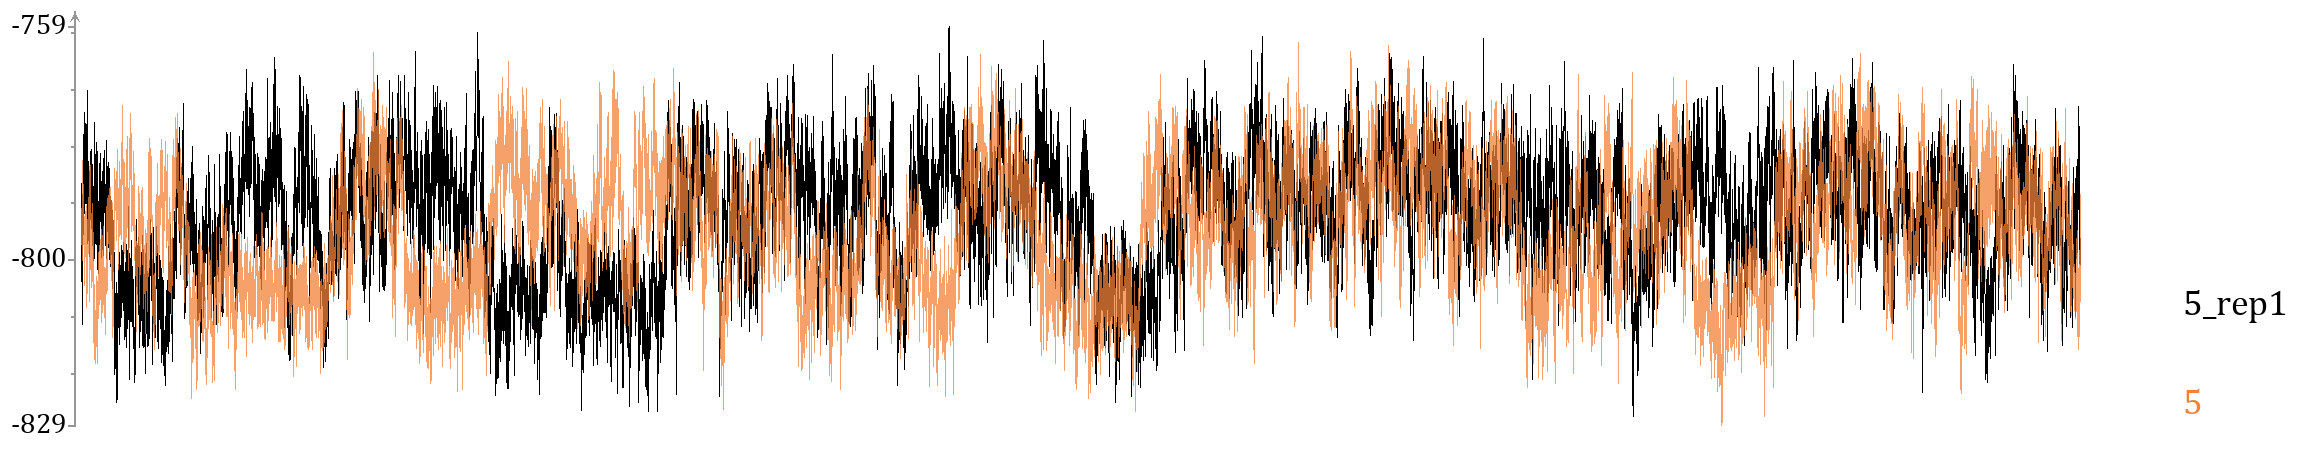

In [16]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.Likelihood, p=1)
P.lines(H2.Likelihood, col='_o', p=1)
(P+L).show()


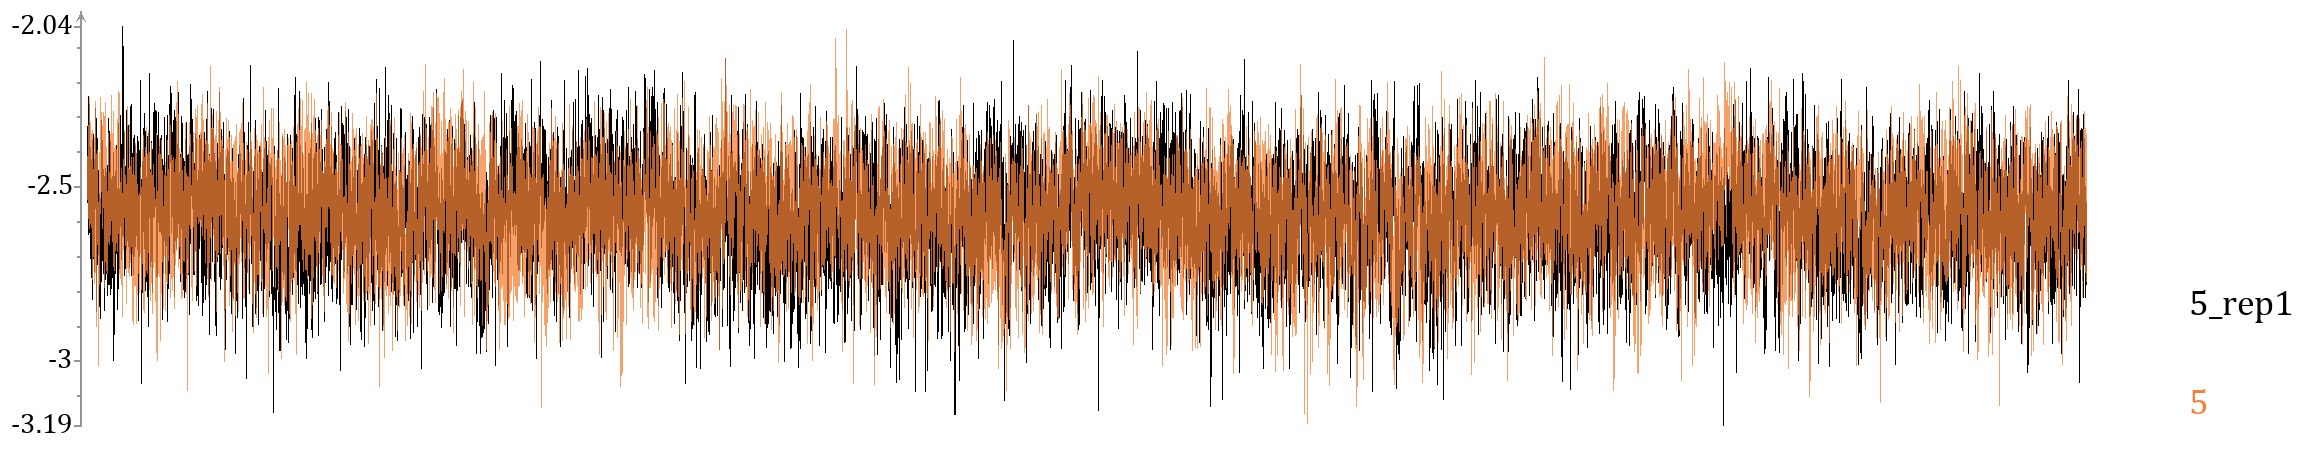

In [17]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.logit_base, p=1)
P.lines(H2.logit_base, col='_o', p=1)
(P+L).show()


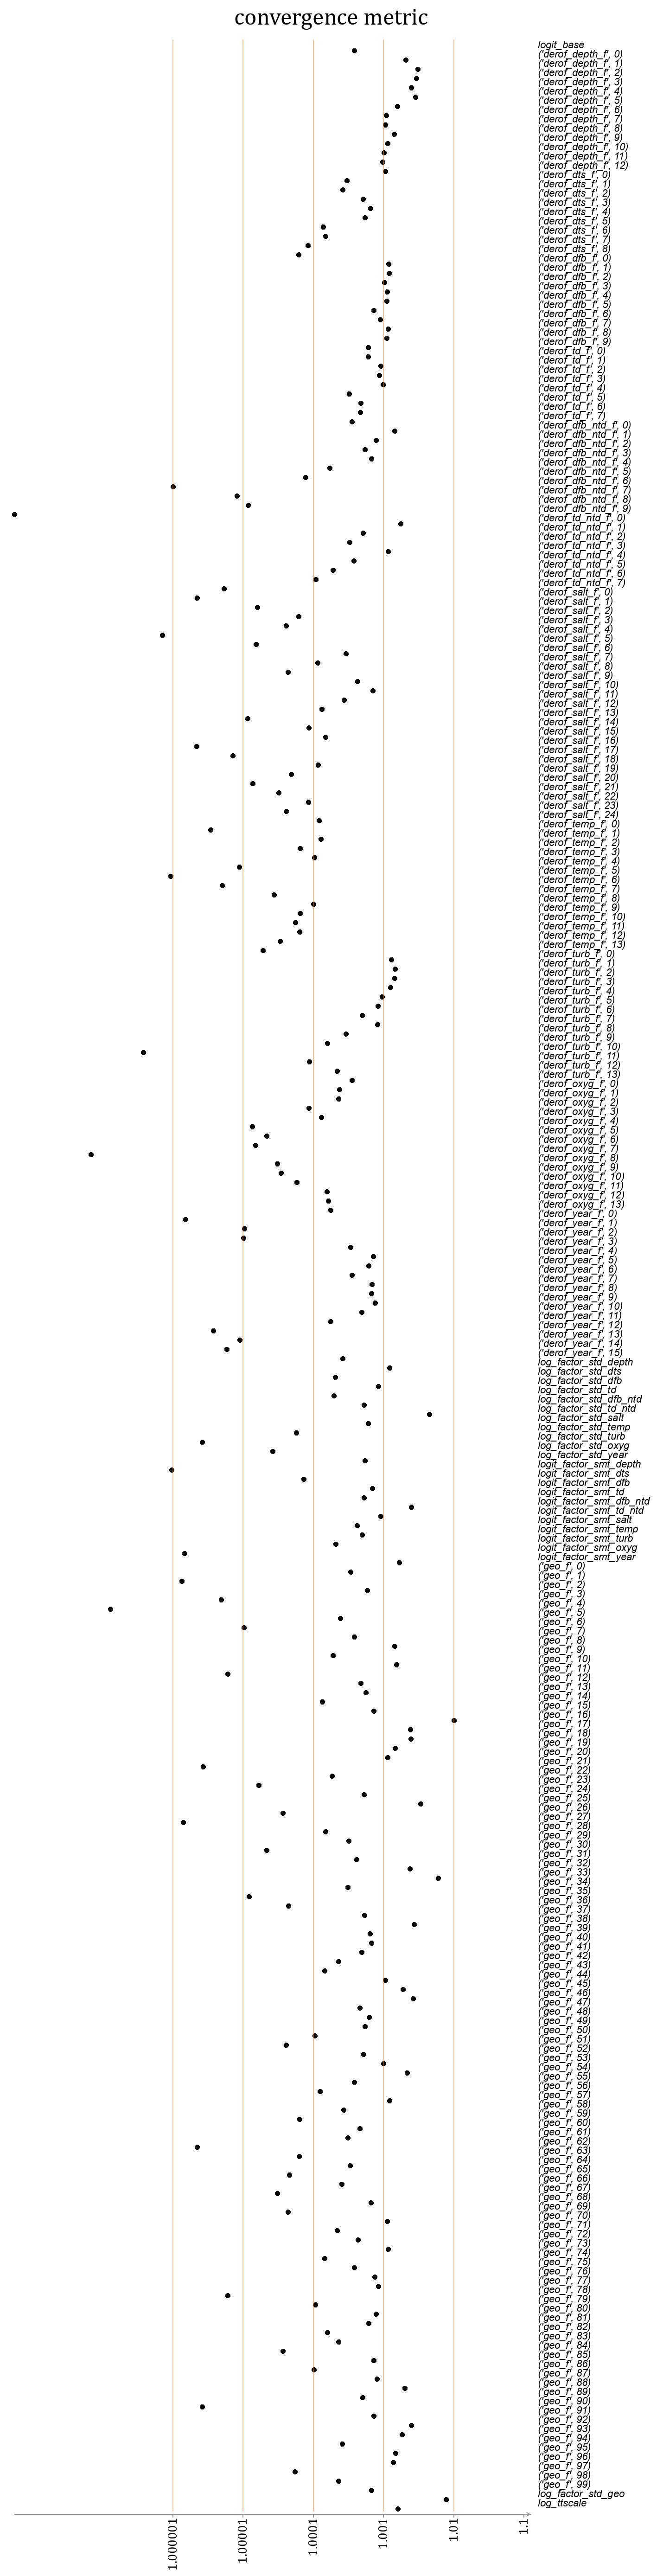

In [18]:
P = artist.Panel(('log', 1100), None, 'vv')

for i, (val, (n, _)) in enumerate(zip(RHAT[s], iterate_columns(H1))):
    P.text(0.1, 0, str(n), pos='>^', font = (22, 'ariali.ttf')).move(30, -i*20)
    P.circle(val-1, 0, r=5).move(0, -i*20)

P.bottom = {float(y)-1:str(y) for y in (1.000001, 1.00001, 1.0001, 1.001, 1.01, 1.1)}
P.grid('v', col='__o')
P.title = 'convergence metric'
P.title.font = 50

P.show()

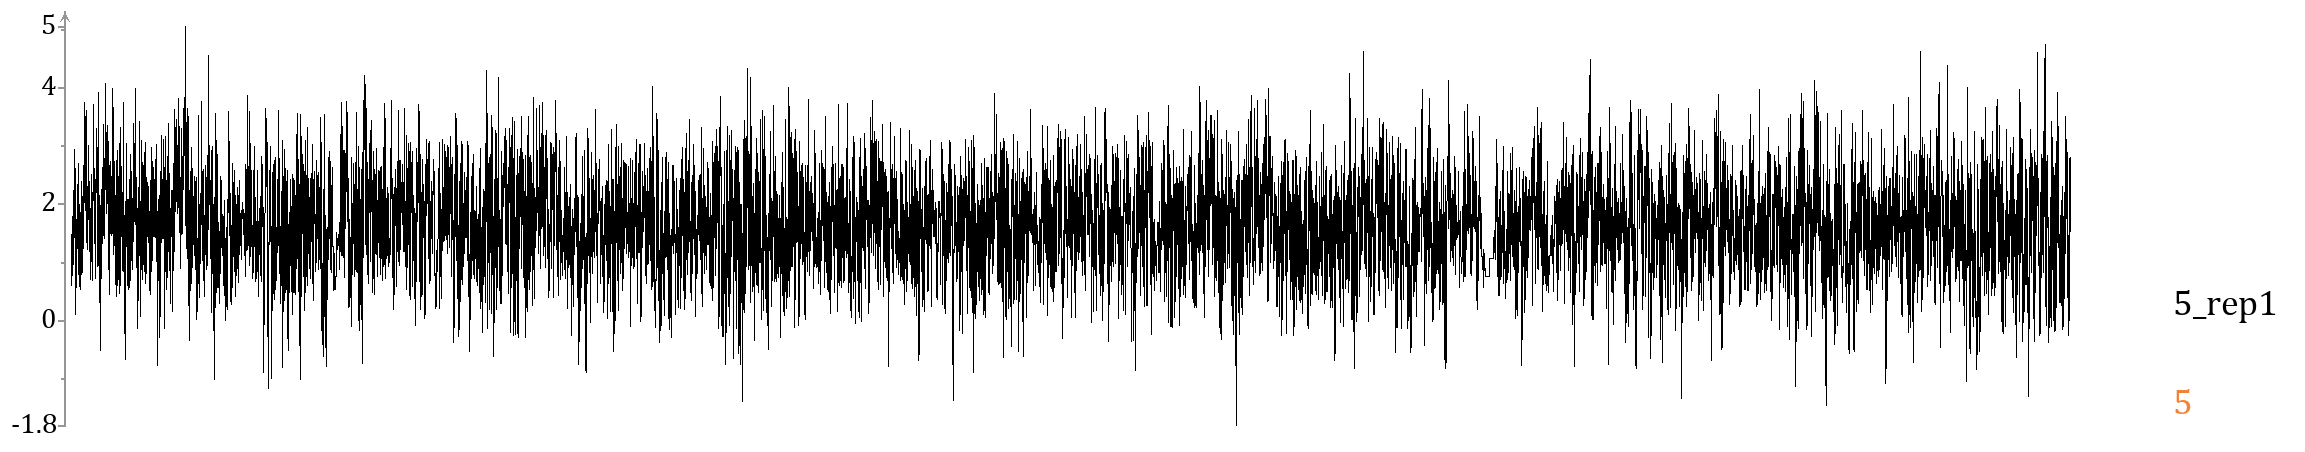

In [19]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.derof_salt_f.str[1], p=1)
#P.lines(H2.derof_salt_f.str[1], col='_o', p=1)
(P+L).show()


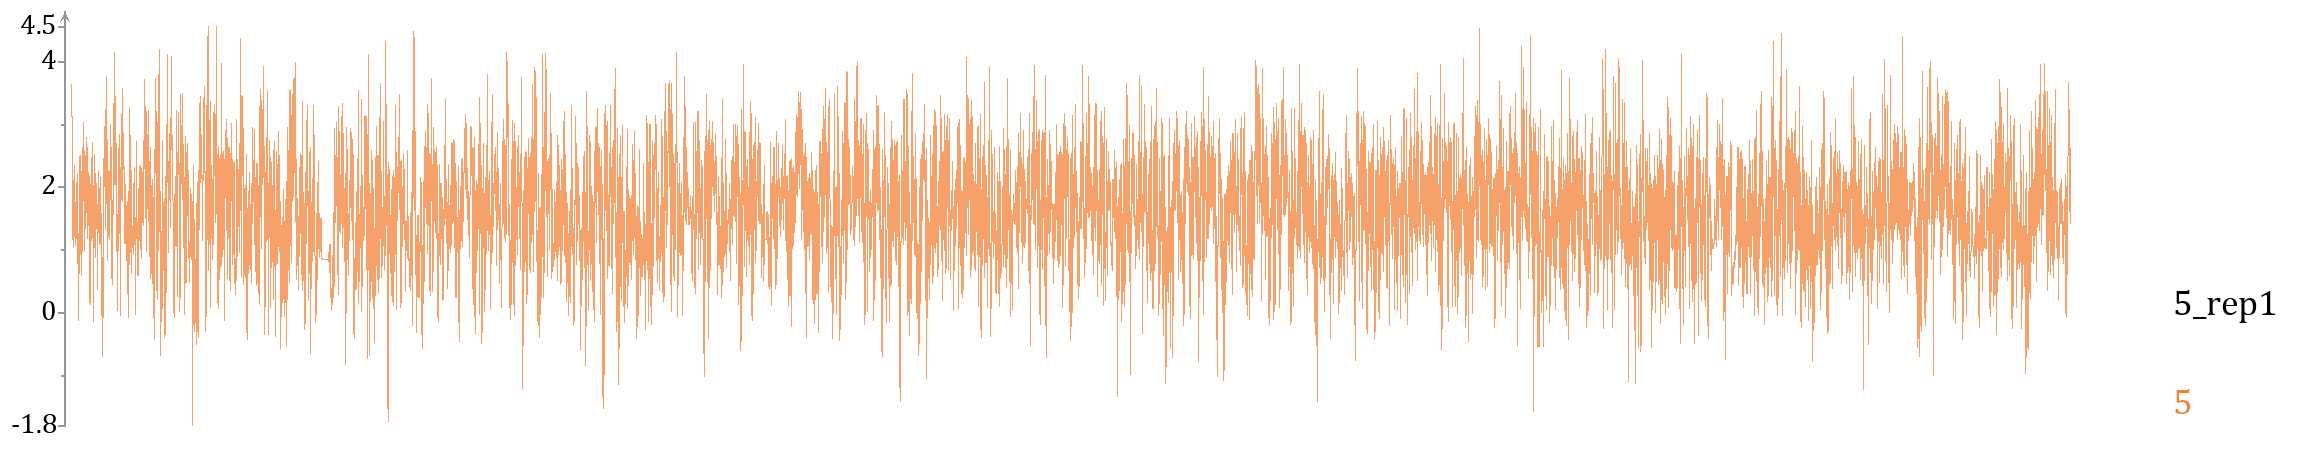

In [20]:
P = artist.Panel(2000, 400, '<<')
#P.lines(H1.derof_salt_f.str[1], p=1)
P.lines(H2.derof_salt_f.str[1], col='_o', p=1)
(P+L).show()


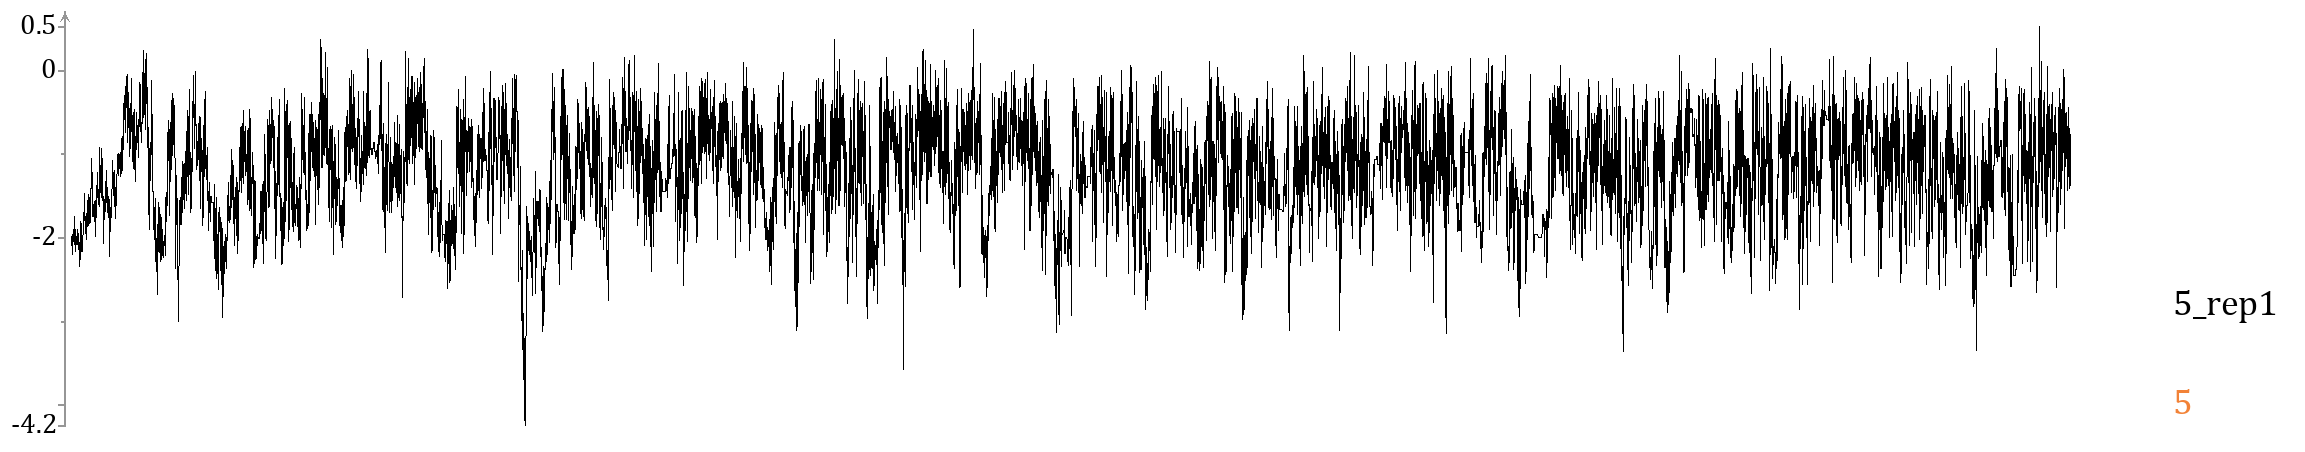

In [21]:
P = artist.Panel(2000, 400, '<<')
P.lines(H1.derof_turb_f.str[6], p=1)
(P+L).show()


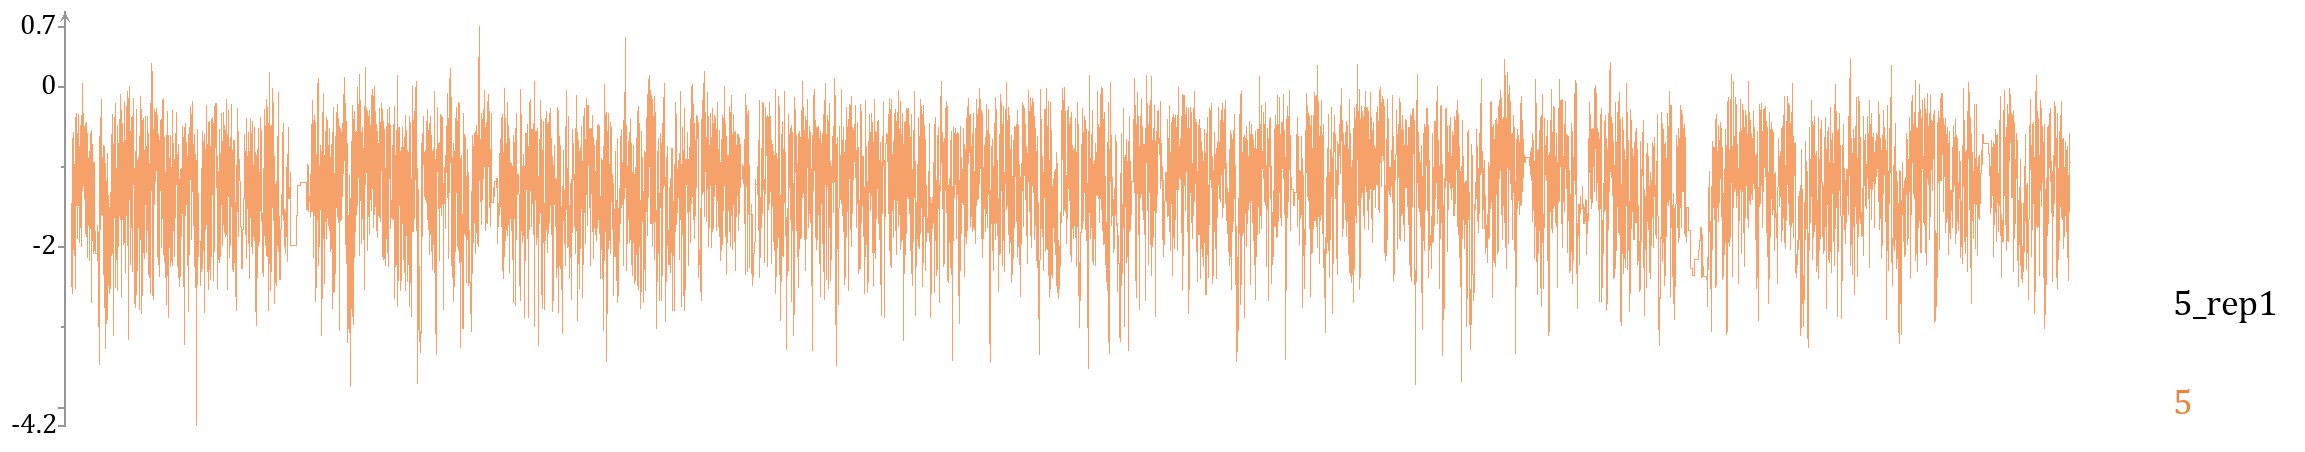

In [22]:
P = artist.Panel(2000, 400, '<<')
P.lines(H2.derof_turb_f.str[6], col='_o', p=1)
(P+L).show()


In [23]:

NUM1 = '5'
NUM2 = '5_rep1'


for i, s in enumerate([SL['flo']]):
    print(i, s)
    
    try:
        TRIAL_N = f'samples/{NUM1}_{s.name}'
        H = data_pers.Load(TRIAL_N, files=[1])
        print(len(H), NUM1)        
        MEANS[s, 1] = {n: c.mean() for n, c in iterate_columns(H)}
        VARS[s, 1] = {n: c.var() for n, c in iterate_columns(H)}

        TRIAL_N = f'samples/{NUM2}_{s.name}'
        H = data_pers.Load(TRIAL_N, files=[1])   
        print(len(H), NUM2)        
        MEANS[s, 2] = {n: c.mean() for n, c in iterate_columns(H)}
        VARS[s, 2] = {n: c.var() for n, c in iterate_columns(H)}
    except:
        print('MISSING!')
    print()
    


0 flo	127141	European flounder
30000 5
30000 5_rep1



In [24]:
RHAT[s] = all_r_hat(s)